## Extra Project 2
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

### <strong style='color:orange ; background-color:black;'> This is a continuation of `ex1_01_main`, where I'm going to try to optimize even further using Tuomas' advice!</strong>



<i>
<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `XGBoost` , `PCA` , `RFE` , `StandardScaler`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |

#### Summary: 

This is a contuation of my very first ML notebook `ex1_01_main.ipynb`. This time, I have around 100 hours of experience in creating ML notebooks, a lot of which were spent in this dataset. I asked Tuomas for some advice, and we're going to try some of those methods. 

<strong style='color:orange ; background-color:black;'> First</strong>, we'll try a blanket method of eliminating feature outliers (scipy Stats)

<strong style='color:orange ; background-color:black;'> Second</strong>, we'll use RFE and PCA in separate experiments and we compare.
 
<strong style='color:orange ; background-color:black;'> Third</strong>, we use VIF test at the end of the notebook. If there's multicollinearity, drop a column and rerun the notebook.

<strong style='color:orange ; background-color:black;'> Fourth</strong>, we use `XGBoost`. I've spent an hour beforehand reading up on how it works.

<strong style='color:orange ; background-color:black;'> Finally</strong>, I give my personal analysis below in the results section to document what I have learned.


#### Results:

| RFE | PCA|
|---|---|
|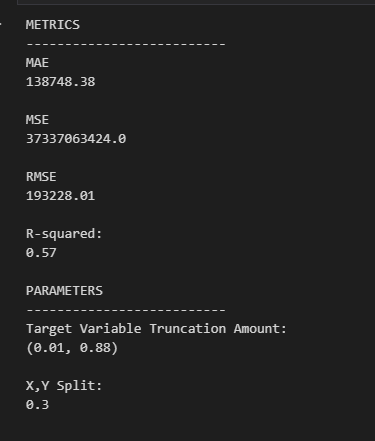|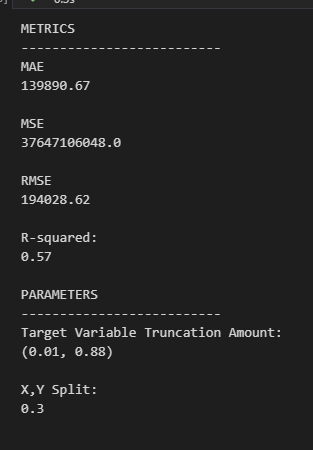|

I applied `StandardScaler` and the same hyperparameters for both attempts in `XGBoost`, while optimizing `RFE` and `PCA`. Both of them ended up performing similarly, but RFA ended up on top by a small margin. Very satisfying result. With the methods I've learned so far, I don't think it will get much better.

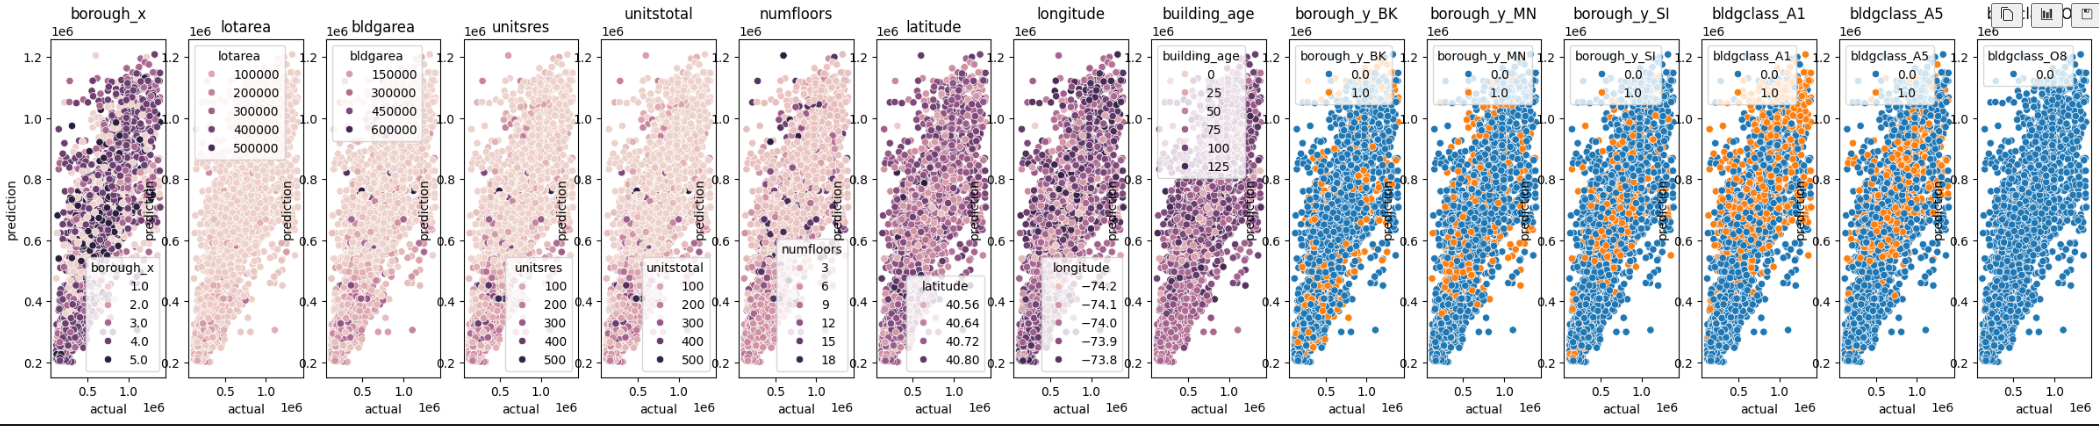

The clusters between features aren't clumped anymore, which is a real healthy sign and shows we're nearing the variance limit of the dataset, plus-or-minus a few outliers.

#### Some lessons I've learned: 

|Lesson No| Lesson|
|---|---|
| 1 | I shouldn't blindly trust the VIF test. Just because something is multicollinear doesn't mean it's useless. Run the model with and without the feature to be sure. `Latitude` and `Longitude` were multicollinear, but having both in the dataset raised the r-squared score by 0.04 and raised MAE by 20,000.|
| 2 |`StandardScaler` is a good option for when numeric ranges get large. Try that first and check the result before doing any fancy stuff.|
| 3 | When you have too many features, experiment with `RFE` and `PCA` and know the tradeoffs. `PCA` combines features and turns them into high-dimensional mega features, while eliminating redundant features. It's incredibly powerful for when you suspect combined features can predict things (for example, debt-to-income ratio). The tradeoff is that it's unsupervised and the result of `PCA` is an uninterpretable combination of features, so interpreting results is a pain. Whereas `RFE` runs a model many times and experiments in batches, eliminating features with each step. It's computationally expensive, but it's really great for when you suspect the features are mostly independent from one-another.|







---

### Code

##### Installing requirements
`pip install -r requirements.txt`

In [ ]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import joblib

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

<br>


#### Checking The Dataframe Shape

In [1033]:
# Checking the amount of columns and rows.
df.shape

(34439, 19)

#### Handling Missing Values

In [1034]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [1035]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [1036]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [1037]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

#### Dropping Columns

<i>
In the cell below, we'll be dropping some of the columns which we know we won't be using. each column has a justification as a side comment. 
</i>



In [ ]:
# Dropping co-dependent/high collinearity columns
df = df.drop([
    # "borough_x",   # Actually related to the SELLER, not the property location. USEFUL.
    # 'latitude',    # Incredibly useful information for XGBoost (r-squared boost .04)
    # 'longitude',   # Incredibly useful information for XGBoost (r-squared boost .04)
    'yearbuilt',     # This is co-dependent with `buildingage`
    'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent. VIF TEST failed
    'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent. VIF TEST failed
    'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
    'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
    'zip_code',      # Too specific, it'll affect distribution.
    'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,borough_x,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,latitude,longitude,bldgclass,building_age
0,1,280000,MN,2404.0,6875.0,18.0,18.0,5.0,40.724415,-73.983891,C6,125.0
1,1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,40.724975,-73.981535,C4,125.0
2,1,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,40.725346,-73.983112,C7,105.0


#### Categorical Feature Isolated Case Elimination

<i>
In the cells below, we'll check the categorical column's value counts. If there isn't enough cases of a certain value, we drop it. I made an image which describes why

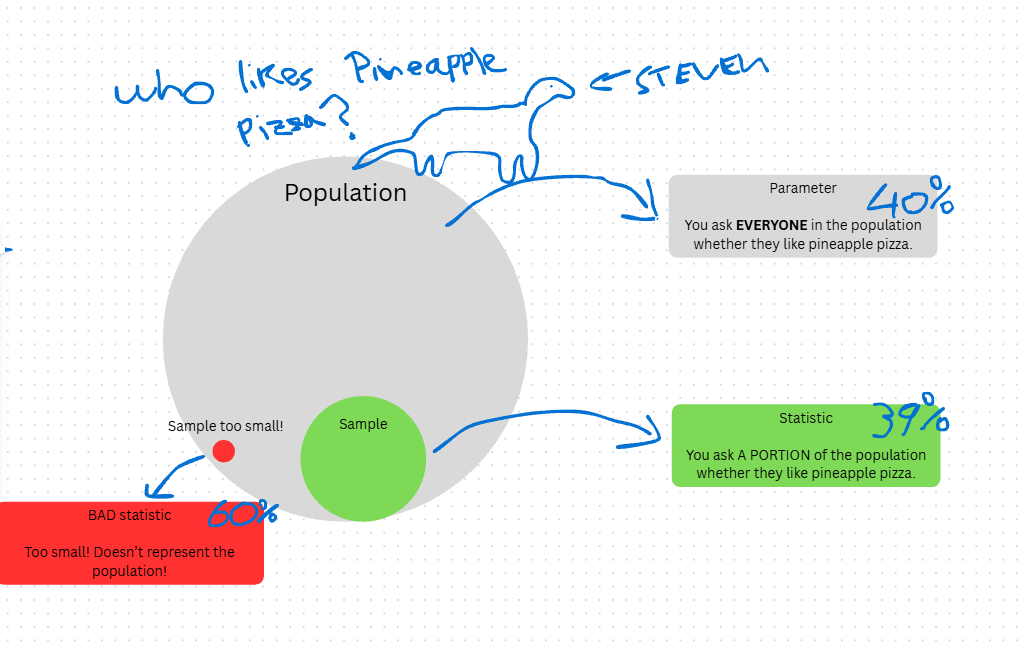

</i>

##### `bldgclass`

In [1039]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts

# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

#### Categorical Feature Isolated Case Elimination

##### `borough_y`

In [1040]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

#### Turning Categorical Columns into Numbers

<i> 
Now, we'll begin turning every possible feature into numbers.
</i>

In [1041]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

df.head(3)

,borough_x,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,latitude,longitude,building_age,...,bldgclass_O2,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9
0,1,280000,2404.0,6875.0,18.0,18.0,5.0,40.724415,-73.983891,125.0,...,0,0,0,0,0,0,0,0,0,0
1,1,2000000,1919.0,7810.0,8.0,10.0,5.0,40.724975,-73.981535,125.0,...,0,0,0,0,0,0,0,0,0,0
2,1,3400000,2150.0,6152.0,8.0,9.0,5.0,40.725346,-73.983112,105.0,...,0,0,0,0,0,0,0,0,0,0


---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Feature Outlier Elimination

<i>

First, we'll deal with all the general outliers

In [ ]:
# version 1, SciPy, extreme outliers that go under -3 or over +3 in normal distribution
from scipy import stats
df = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]



####  Target Variable Outlier & Skew Elimination

<i>
We're also going to cut off a bit extra off the target variable, since it's a mess (VERY right-skewed). I ran the result with various approaches. Truncation with a high cutoff gave the best result.
</i>

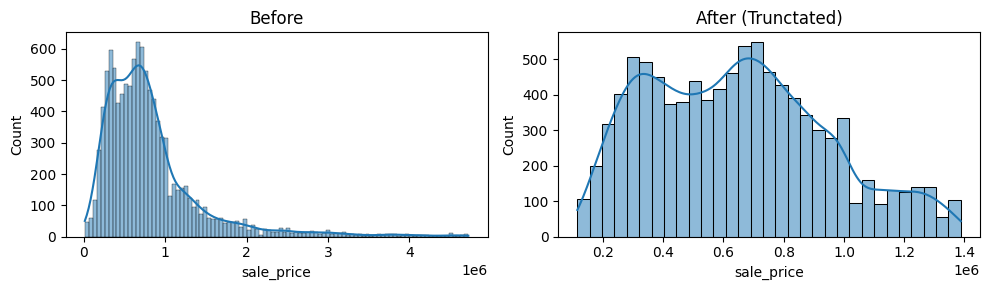

Rows left: 9581


In [1043]:
# Target variable cutoffs 
y_trunc_floor = 0.01
y_trunc_ceiling = 0.88

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Histplot 0
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df["sale_price"] >= df["sale_price"].quantile(q=y_trunc_floor)) &
    (df["sale_price"] <= df["sale_price"].quantile(q=y_trunc_ceiling))
    ]

# Histplot 1
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)

# Plot titles
axes[0].set_title("Before")
axes[1].set_title("After (Trunctated)")
plt.tight_layout()
plt.show()

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

# Since this is eliminating information, we won't have to worry about a data leak here.

#### 

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Advanced Tasks|


#### ML Model Training & Logging
##### Using `XGBOOST`



<i>

For this section, we're going to make two models. One model will use `RFE` feature selection, the other will use `PCA` selection. I experimented with the model's hyperparameters quite a bit. I know that the `learning-rate`, `max_depth`, and `n_estimators` are mostly locked in at it's optimal value. 
 </i>

<br>

`RFE`

For `RFE`, we'll use the same hyperparameters for feature selection for the training, since it didn't slow down the performance much (1.4s). I experimented `n_features_to_select` but kept `step` high enough so it doesn't hinder performance. 


In [ ]:
from sklearn.feature_selection import RFE
import xgboost as xgb

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df.drop("sale_price", axis=1)
y = df['sale_price']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# USING RFE with xgboost
rfe = RFE(xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42      
), n_features_to_select=15, step=3)

# These hyperparameters kind of remind me of `CatBoostRegressor`!

X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# make_pipeline
pipeline = make_pipeline(
    StandardScaler(),
    xgb.XGBRegressor(n_estimators=100,max_depth=8,learning_rate=0.05,random_state=42)
)

# Initalize and fit the model.
pipeline.fit(X_train_selected, y_train)

# Predict the data with the model.
predictions = pipeline.predict(X_test_selected)

# Save the model using joblib
joblib.dump(pipeline, "models/ex1_extra2.pkl")

# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
138748.38 

MSE
37337063424.0 

RMSE
193228.01 

R-squared:
0.57 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.88) 

X,Y Split:
0.3



`PCA`

In [1045]:

from sklearn.decomposition import PCA

# Step 2: Run a make_pipeline. Using the chaining method across all features
# from Tuomas' snippet. 
pipeline = make_pipeline(
    # Step 1: StandardScaler
    StandardScaler(),

    # Step 2: Use PCA and create 20-high dimensional features.
    PCA(n_components=20),

    # Step 3: Train / Predict using Model.
    xgb.XGBRegressor(n_estimators=100,max_depth=8,learning_rate=0.05,random_state=42)
)

# Initalize and fit the model.
pipeline.fit(X_train, y_train)

# Predict the data with the model.
predictions = pipeline.predict(X_test)

# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)


# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
139890.67 

MSE
37647106048.0 

RMSE
194028.62 

R-squared:
0.57 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.88) 

X,Y Split:
0.3



In [1046]:
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.88) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<i>
Awful result, but I've been on this notebook for maybe 30-40 hours. I've done a number of transformations, some feature selection, and learned quite a bit about dataleaks. Nothing. The dataset is likely just too broad.
</i>

<Axes: xlabel='sale_price'>

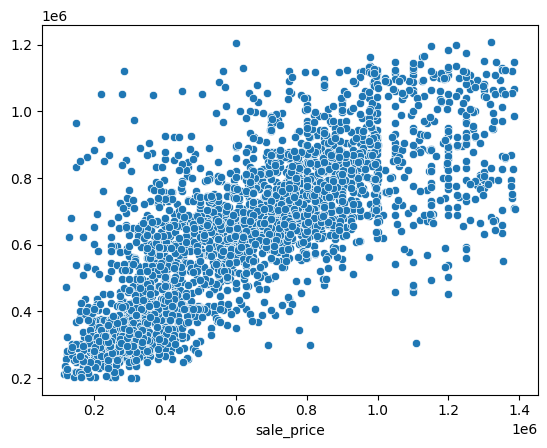

In [1047]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

<i>

A bit of a strange cutoff section at the end, but I don't BELIEVE this should affect the results much. Much more linear, but still has some linearity issues.

---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6| Advanced Tasks|

<i> So, what went wrong? </i>

#### Creating a Dataframe with `predicted_price` and `error_margin`

<i>
This is mostly used for myself. I'm creating a dataframe that easily lets us check the results in one dataframe. It's useful to have a DataFrame with the predictions and actuals all-in-one.
</i>

In [1048]:
# Get all the features names using rfe.get_support()
selected_features = X_train.columns[rfe.get_support()]

# Create the dataframe from X_test_selected, with `selected_features` as the columns
# I use the index as y_test so it can match them as-is.
results_df = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=y_test.index 
)

results_df["prediction"] = predictions
results_df["actual"] = y_test


In [1049]:
results_df

,borough_x,lotarea,bldgarea,unitsres,unitstotal,numfloors,latitude,longitude,building_age,borough_y_BK,borough_y_MN,borough_y_SI,bldgclass_A1,bldgclass_A5,bldgclass_O8,prediction,actual
16227,3.0,1825.0,1825.0,1.0,1.0,2.0,40.620006,-73.939632,85.0,1.0,0.0,0.0,0.0,1.0,0.0,8.066594e+05,810000
32810,5.0,2550.0,1360.0,1.0,1.0,2.0,40.572020,-74.126117,60.0,0.0,0.0,1.0,0.0,1.0,0.0,6.701788e+05,696105
19973,4.0,210000.0,336200.0,314.0,314.0,13.0,40.760818,-73.759223,64.0,0.0,0.0,0.0,0.0,0.0,0.0,3.729787e+05,400000
16462,3.0,2600.0,1734.0,1.0,1.0,2.0,40.613476,-73.951790,105.0,1.0,0.0,0.0,1.0,0.0,0.0,1.099738e+06,1175000
26908,4.0,327788.0,243396.0,270.0,270.0,6.0,40.738283,-73.761274,73.0,0.0,0.0,0.0,0.0,0.0,0.0,2.789117e+05,251000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34286,5.0,868.0,1360.0,1.0,1.0,3.0,40.604374,-74.132340,37.0,0.0,0.0,1.0,0.0,1.0,0.0,6.293032e+05,510000
30404,4.0,2700.0,1308.0,1.0,1.0,2.5,40.744738,-73.905563,95.0,0.0,0.0,0.0,1.0,0.0,0.0,1.102228e+06,760000
30594,4.0,94807.0,441929.0,442.0,442.0,12.0,40.746691,-73.910992,62.0,0.0,0.0,0.0,0.0,0.0,0.0,4.518869e+05,360000
30747,5.0,4000.0,1662.0,1.0,1.0,2.0,40.759876,-73.780837,105.0,0.0,0.0,0.0,1.0,0.0,0.0,7.334412e+05,310000


#### Creating a Scatterplot with hue as different used features

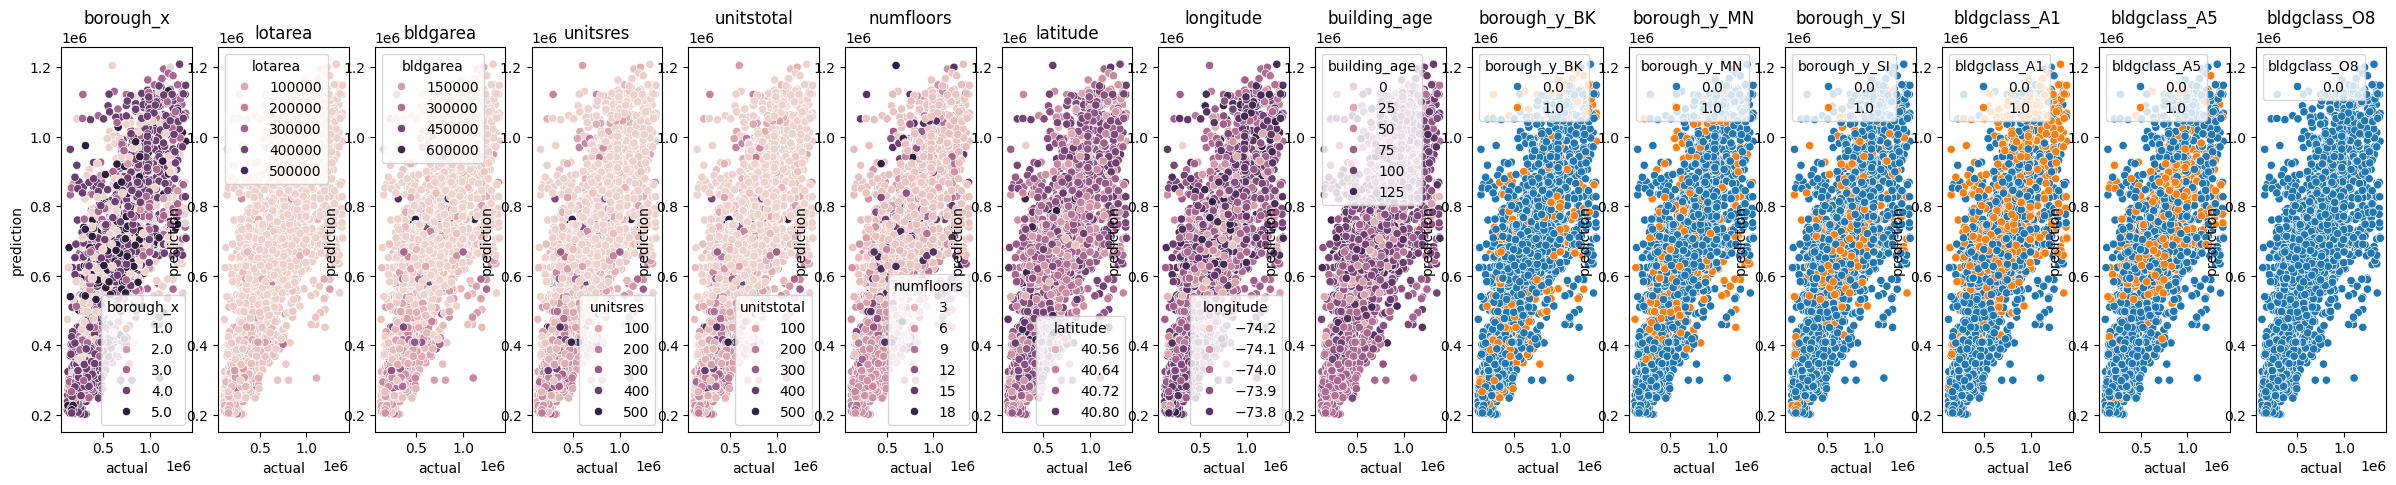

In [1050]:

# This makes a scatterplot for every predictive feature in X. 

# Take a small amount of the case dataframe. 

# The number of features in the model.
feature_amount = len(selected_features)

# Create a multiplot canvas with the amount of features as the number of plot.
fig, axes = plt.subplots(1, feature_amount , figsize=(30, 5))

# turn each plot into a scatterplot for every feature in the list.
for index, feature in enumerate(selected_features):
    sns.scatterplot(results_df, x="actual", y="prediction", hue=feature, ax=axes[index])
    axes[index].set_title(feature)
    

#### Post analysis VIF TEST

<i> This part is just to see if we can get rid of some multi-collinearity features (if I see any, I'll just rerun the notebook.)

In [1053]:
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

features_df = pd.DataFrame(X_train_selected)

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = features_df.columns
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(features_df.values, i) 
                          for i in range(len(features_df.columns))] 
  

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression
print(vif_data)

    feature            VIF
0         0      24.066989
1         1       3.454227
2         2      30.375079
3         3    7836.178221
4         4    7871.434030
5         5      11.256303
6         6  894252.902389
7         7  898717.813247
8         8      18.877672
9         9       4.682068
10       10       4.738383
11       11      10.258104
12       12       5.692741
13       13       4.882942
14       14            NaN


c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


<i> Exceptions to VIF:

Feature 6-7 is latitude and longitude. Getting rid of these features actually gives a worse result. Makes sense, since land/plots are all about LOCATION, LOCATION, LOCATION. In `LinearRegression` it was useless though. I suppose that also makes sense, since the relationship isn't linear! I suppose that's where `PolynomialFeatures` really could have helped here. 

Feature 3-4 is `unitsres` and `unitstotal`. They're not completely multicollinear, since one refers to total buildings and the other refers to residential units. `XGBoost` seems to eliminat much of that redundancy.